# Title : Comparative Analysis of Deep Learning–Based Semantic Segmentation Models for Water Body Extraction from Remote Sensing Imagery

# Importing Libraries

In [ ]:
# I imported the OS module to handle file paths and directory operations
import os

# I imported NumPy to perform numerical computations and array manipulations
import numpy as np

# I imported Matplotlib to visualize images, graphs, and model performance plots
import matplotlib.pyplot as plt

# I imported Seaborn to create enhanced statistical visualizations such as heatmaps and distributions
import seaborn as sns

# I imported TensorFlow to build, train, and evaluate the deep learning model
import tensorflow as tf

# I imported train_test_split to divide the dataset into training and testing subsets
from sklearn.model_selection import train_test_split

# I imported image loading utilities to read and convert images into arrays for model input
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# I imported ImageDataGenerator to perform real-time data augmentation during model training
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# I imported kagglehub to download and access datasets directly from Kaggle within the notebook
import kagglehub

# Downloading the dataset

In [ ]:
# I downloaded the water body satellite image dataset directly from Kaggle using kagglehub
path = kagglehub.dataset_download(
    "franciscoescobar/satellite-images-of-water-bodies"
)

# I printed the local directory path to confirm where the dataset was stored
print("Dataset downloaded to:", path)

100%|██████████| 247M/247M [00:01<00:00, 141MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/franciscoescobar/satellite-images-of-water-bodies/versions/2


# Loading the dataset

In [ ]:
# I defined the dataset directory paths for images and corresponding segmentation masks
image_folder = f"{path}/Water Bodies Dataset/Images"
mask_folder  = f"{path}/Water Bodies Dataset/Masks"

# I created a function to load images and masks from the dataset folders and resize them
def load_images_from_folder(img_folder, mask_folder, img_size=(256, 256)):
    images, masks = [], []

    # I iterated through each image filename in the dataset
    for filename in os.listdir(img_folder):
        img_path  = os.path.join(img_folder, filename)
        mask_path = os.path.join(mask_folder, filename)

        # I ensured both image and corresponding mask existed before processing
        if os.path.exists(img_path) and os.path.exists(mask_path):

            # I loaded and resized the RGB satellite image
            img  = load_img(img_path,  target_size=img_size)

            # I loaded and resized the mask image in grayscale format
            mask = load_img(mask_path, target_size=img_size, color_mode="grayscale")

            # I converted images to arrays and normalized pixel values between 0 and 1
            img  = img_to_array(img) / 255.0
            mask = img_to_array(mask) / 255.0

            # I converted the mask into binary format (water = 1, background = 0)
            mask = (mask > 0.5).astype(np.float32)

            # I appended processed image and mask to their respective lists
            images.append(img)
            masks.append(mask)

    # I converted the lists into NumPy arrays for model training
    return np.array(images), np.array(masks)

# I loaded the full dataset using the defined function
X, y = load_images_from_folder(image_folder, mask_folder)

# I printed dataset shapes to verify successful loading and preprocessing
print("Images shape:", X.shape)
print("Masks shape:", y.shape)

Images shape: (2841, 256, 256, 3)
Masks shape: (2841, 256, 256, 1)


# Exploratory Data Analysis

Number of images: 2841
Image shape: (256, 256, 3)
Mask shape: (256, 256, 1)
Unique mask values: [0. 1.]


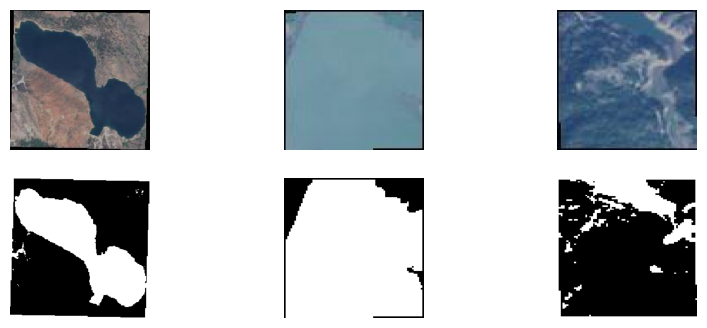

In [ ]:
# I printed the total number of images available in the dataset
print("Number of images:", X.shape[0])

# I displayed the shape of each image (height, width, channels)
print("Image shape:", X.shape[1:])

# I displayed the shape of each segmentation mask
print("Mask shape:", y.shape[1:])

# I checked the unique values in masks to confirm they were binary (0 and 1)
print("Unique mask values:", np.unique(y))

# I created a figure to visualize sample images and their corresponding masks
plt.figure(figsize=(10,4))

# I plotted the first three images along with their masks
for i in range(3):

    # I displayed the original satellite image
    plt.subplot(2,3,i+1)
    plt.imshow(X[i])
    plt.axis("off")

    # I displayed the corresponding ground truth mask in grayscale
    plt.subplot(2,3,i+4)
    plt.imshow(y[i].squeeze(), cmap="gray")
    plt.axis("off")

# I rendered the visualization
plt.show()

# Splitting the dataset

In [ ]:
# I split the dataset into training and testing sets using an 80–20 ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# I further divided the training data to create a validation set (10% of the training data)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42
)

# I printed the shapes of each dataset to verify the splitting process
print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Train: (2044, 256, 256, 3)
Val:   (228, 256, 256, 3)
Test:  (569, 256, 256, 3)


# Data Augmentation

In [ ]:
# I defined the batch size and fixed the random seed for reproducibility
BATCH_SIZE = 8
seed = 42

# I created augmentation settings to artificially expand the training dataset
data_gen_args = dict(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="nearest"
)

# I initialized separate data generators for images and masks using the same augmentation parameters
image_datagen = ImageDataGenerator(**data_gen_args)
mask_datagen  = ImageDataGenerator(**data_gen_args)

# I fitted the generators to the training data so that transformations remained consistent
image_datagen.fit(X_train, seed=seed)
mask_datagen.fit(y_train, seed=seed)

# I created a custom generator that yielded augmented image–mask pairs during training
def train_generator(batch_size=BATCH_SIZE, seed=seed):
    img_gen  = image_datagen.flow(X_train, batch_size=batch_size, seed=seed)
    mask_gen = mask_datagen.flow(y_train, batch_size=batch_size, seed=seed)
    while True:
        yield next(img_gen), next(mask_gen)

# I prepared the validation generator without augmentation and disabled shuffling
val_gen = ImageDataGenerator().flow(
    X_val, y_val, batch_size=BATCH_SIZE, shuffle=False
)

# SEGMENTATION METRICS (IoU & Dice)

In [ ]:
# I defined the Intersection over Union (IoU) metric to measure overlap between predicted and true masks
def iou_metric(y_true, y_pred, smooth=1e-7):
    # I converted predicted probabilities into binary values using a threshold of 0.5
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    # I calculated the intersection and union areas
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection

    # I returned the IoU score with smoothing to avoid division by zero
    return (intersection + smooth) / (union + smooth)


# I implemented the Dice coefficient to evaluate segmentation similarity
def dice_coef(y_true, y_pred, smooth=1e-7):
    # I binarized the predictions
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    # I computed the overlap between ground truth and prediction
    intersection = tf.reduce_sum(y_true * y_pred)

    # I calculated the Dice score
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )


# I implemented the F1-score metric for segmentation performance evaluation
def f1_score(y_true, y_pred, smooth=1e-7):
    # I converted predictions to binary masks
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    # I calculated true positives, false positives, and false negatives
    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))

    # I returned the F1 score with smoothing to prevent division errors
    return (2 * tp + smooth) / (2 * tp + fp + fn + smooth)

# LOSS FUNCTION (BCE + DICE)

In [ ]:
def dice_loss(y_true, y_pred):
    # I defined the Dice loss function to measure the overlap between the predicted segmentation and the true mask.
    # I calculated it as (1 - Dice coefficient) so that minimizing the loss would maximize the similarity.
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    # I combined Binary Cross-Entropy (BCE) with Dice loss to improve segmentation performance.
    # I used BCE to measure pixel-wise classification error between the true labels and predictions.
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)

    # I added Dice loss to ensure better overlap between the predicted mask and the ground truth mask.
    # This helped balance both pixel accuracy and region similarity during model training.
    return bce + dice_loss(y_true, y_pred)

# COMPILE FUNCTION & CALLBACKS

In [ ]:
def compile_model(model, lr=1e-4):
    # I created this function to compile the model with the required optimizer, loss function, and evaluation metrics.

    model.compile(
        # I used the Adam optimizer because it provides efficient and adaptive learning during training.
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),

        # I used the combined Binary Cross Entropy and Dice loss to improve segmentation performance.
        loss=bce_dice_loss,

        # I included multiple metrics to evaluate the model performance from different perspectives.
        # Accuracy measured pixel-wise correctness, IoU measured region overlap,
        # Dice coefficient measured segmentation similarity, and F1-score evaluated balance between precision and recall.
        metrics=["accuracy", iou_metric, dice_coef, f1_score]
    )

    # I returned the compiled model so it could be used for training.
    return model


# I set the number of training epochs to 20 so that the model could learn sufficiently from the data.
EPOCHS = 20

# I calculated the number of steps per epoch based on the size of the training dataset and batch size.
STEPS_PER_EPOCH = len(X_train) // BATCH_SIZE

# I calculated the number of validation steps using the validation dataset size.
VAL_STEPS = len(X_val) // BATCH_SIZE


# I implemented EarlyStopping to prevent overfitting during training.
early_stop = tf.keras.callbacks.EarlyStopping(

    # I monitored the validation IoU metric because it reflects segmentation performance.
    monitor="val_iou_metric",

    # I set the mode to "max" since higher IoU values indicate better performance.
    mode="max",

    # I allowed the model to continue training for 7 epochs without improvement before stopping.
    patience=7,

    # I restored the best model weights obtained during training.
    restore_best_weights=True
)

# MODEL ARCHITECTURES (DEFINED ONCE)

# Simple U-Net (Baseline Semantic Segmentation)

In [ ]:
from tensorflow.keras import layers, Model

def simple_unet(input_shape=(256, 256, 3)):

    # I defined the input layer to accept images of size 256x256 with 3 color channels (RGB).
    inputs = layers.Input(input_shape)


    # Encoder (Downsampling Path)
    # I applied a convolution layer with 16 filters to extract basic spatial features from the input image.
    c1 = layers.Conv2D(16, 3, activation="relu", padding="same")(inputs)

    # I used a MaxPooling layer to reduce the spatial dimensions and capture more abstract features.
    p1 = layers.MaxPooling2D()(c1)

    # I added another convolution layer with 32 filters to learn deeper and more complex feature representations.
    c2 = layers.Conv2D(32, 3, activation="relu", padding="same")(p1)

    # I again applied MaxPooling to further reduce the feature map size while increasing receptive field.
    p2 = layers.MaxPooling2D()(c2)


    # Bottleneck
    # I implemented the bottleneck layer with 64 filters to capture the most compressed and high-level features.
    b = layers.Conv2D(64, 3, activation="relu", padding="same")(p2)


    # Decoder (Upsampling Path)
    # I used UpSampling to increase the spatial resolution of the feature maps.
    u2 = layers.UpSampling2D()(b)

    # I concatenated the upsampled features with the corresponding encoder features (skip connection) to preserve spatial information.
    u2 = layers.Concatenate()([u2, c2])

    # I applied another convolution layer to refine the combined features.
    c3 = layers.Conv2D(32, 3, activation="relu", padding="same")(u2)

    # I again performed upsampling to restore the feature maps closer to the original input resolution.
    u1 = layers.UpSampling2D()(c3)

    # I concatenated these features with the earlier encoder layer to maintain fine-grained spatial details.
    u1 = layers.Concatenate()([u1, c1])

    # I applied a convolution layer with 16 filters to further refine the reconstructed features.
    c4 = layers.Conv2D(16, 3, activation="relu", padding="same")(u1)


    # Output Layer
    # I used a 1x1 convolution with sigmoid activation to generate the final segmentation mask.
    # This layer produced a single-channel output representing the probability of each pixel belonging to the target class.
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c4)

    # I created and returned the U-Net model.
    return Model(inputs, outputs, name="Simple_UNet")

# Fully Convolutional Neural Network(FCN)

In [ ]:
def fcn_segmentation(input_shape=(256, 256, 3)):
    # I defined the input layer with the given image shape
    inputs = layers.Input(input_shape)

    # I applied the first convolution layer to extract low-level features
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)

    # I reduced the spatial dimensions using max pooling
    x = layers.MaxPooling2D()(x)

    # I applied a second convolution layer to learn more complex features
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)

    # I further downsampled the feature maps
    x = layers.MaxPooling2D()(x)

    # I applied a deeper convolution layer to capture high-level semantic features
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)

    # I upsampled the feature maps to restore the original spatial resolution
    x = layers.UpSampling2D()(x)
    x = layers.UpSampling2D()(x)

    # I applied a final convolution layer with sigmoid activation for pixel-wise classification
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(x)

    # I created and returned the FCN model
    return Model(inputs, outputs, name="FCN")

# Improved Attention + Residual U-Net

In [ ]:
def residual_block(x, filters):
    # I created a shortcut connection using a 1x1 convolution to match dimensions
    shortcut = layers.Conv2D(filters, 1, padding="same")(x)

    # I applied the first convolution with ReLU activation to extract features
    x = layers.Conv2D(filters, 3, activation="relu", padding="same")(x)

    # I applied a second convolution to further refine the feature representation
    x = layers.Conv2D(filters, 3, padding="same")(x)

    # I added the shortcut connection to the main path (residual learning)
    x = layers.Add()([x, shortcut])

    # I applied ReLU activation after combining both paths
    return layers.Activation("relu")(x)


def attention_gate(x, g, filters):
    # I applied a 1x1 convolution to the encoder feature map (x)
    theta_x = layers.Conv2D(filters, 1, padding="same")(x)

    # I applied a 1x1 convolution to the gating signal (g) from decoder
    phi_g = layers.Conv2D(filters, 1, padding="same")(g)

    # I combined both transformed feature maps
    add = layers.Add()([theta_x, phi_g])

    # I applied ReLU activation to introduce non-linearity
    act = layers.Activation("relu")(add)

    # I generated an attention map using sigmoid activation
    att = layers.Conv2D(1, 1, activation="sigmoid")(act)

    # I multiplied the attention map with the input feature map to focus on important regions
    return layers.Multiply()([x, att])


def improved_unet(input_shape=(256, 256, 3)):
    # I defined the input layer with the given shape
    inputs = layers.Input(input_shape)

    # I built the encoder (downsampling path) using residual blocks
    c1 = residual_block(inputs, 16)
    p1 = layers.MaxPooling2D()(c1)

    c2 = residual_block(p1, 32)
    p2 = layers.MaxPooling2D()(c2)

    c3 = residual_block(p2, 64)
    p3 = layers.MaxPooling2D()(c3)

    # I created the bottleneck layer to capture deep features
    b = residual_block(p3, 128)

    # I started the decoder (upsampling path)
    u3 = layers.UpSampling2D()(b)

    # I applied attention gating to filter relevant encoder features
    a3 = attention_gate(c3, u3, 64)

    # I concatenated attention-refined features with upsampled features and applied residual block
    c6 = residual_block(layers.Concatenate()([u3, a3]), 64)

    u2 = layers.UpSampling2D()(c6)
    a2 = attention_gate(c2, u2, 32)
    c7 = residual_block(layers.Concatenate()([u2, a2]), 32)

    u1 = layers.UpSampling2D()(c7)
    a1 = attention_gate(c1, u1, 16)
    c8 = residual_block(layers.Concatenate()([u1, a1]), 16)

    # I used a 1x1 convolution with sigmoid activation to generate the final segmentation mask
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c8)

    # I created the final model combining inputs and outputs
    return Model(inputs, outputs, name="Attention_ResUNet")

# DeepLabV3-Lite (Atrous Convolution)

In [ ]:
def deeplab_v3_lite(input_shape=(256, 256, 3)):
    # I defined the input layer with the specified image shape
    inputs = layers.Input(input_shape)

    # I applied an initial convolution to extract low-level features
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(inputs)

    # I reduced the spatial dimensions using max pooling
    x = layers.MaxPooling2D()(x)

    # I applied another convolution to capture more complex features
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)

    # I implemented ASPP (Atrous Spatial Pyramid Pooling) to capture multi-scale context

    # I applied a 1x1 convolution with dilation rate 1 (standard convolution)
    conv1 = layers.Conv2D(128, 1, dilation_rate=1, padding="same", activation="relu")(x)

    # I applied a 3x3 convolution with dilation rate 6 to capture medium-scale features
    conv6 = layers.Conv2D(128, 3, dilation_rate=6, padding="same", activation="relu")(x)

    # I applied a 3x3 convolution with dilation rate 12 to capture large-scale features
    conv12 = layers.Conv2D(128, 3, dilation_rate=12, padding="same", activation="relu")(x)

    # I concatenated all ASPP feature maps to combine multi-scale information
    x = layers.Concatenate()([conv1, conv6, conv12])

    # I applied a 1x1 convolution to fuse the concatenated features
    x = layers.Conv2D(128, 1, activation="relu")(x)

    # I upsampled the feature map back to higher resolution using bilinear interpolation
    x = layers.UpSampling2D(size=(2, 2), interpolation="bilinear")(x)

    # I applied the final 1x1 convolution with sigmoid activation to produce the segmentation mask
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(x)

    # I created the final DeepLabV3 Lite model
    return Model(inputs, outputs, name="DeepLabV3_Lite")

# Training and Evaluation of the Models

# U-Net Algorithm

In [ ]:
# I built the simple U-Net model architecture
model_simple = simple_unet()

# I compiled the model by defining loss function, optimizer, and evaluation metrics
model_simple = compile_model(model_simple)

# I trained the model using the training data generator
history_simple = model_simple.fit(
    train_generator(),  # I provided the training data using a generator
    steps_per_epoch=STEPS_PER_EPOCH,  # I defined how many batches were processed per epoch
    epochs=EPOCHS,  # I set the total number of training epochs
    validation_data=val_gen,  # I used validation data to monitor model performance
    validation_steps=VAL_STEPS,  # I specified validation steps per epoch
    callbacks=[early_stop],  # I applied early stopping to prevent overfitting
    verbose=1  # I enabled detailed training output
)

# I evaluated the trained model on the test dataset
res_simple = model_simple.evaluate(X_test, y_test, verbose=0)

# I printed the evaluation metrics including IoU, Dice coefficient, and F1-score
print(
    "Simple U-Net → "
    "IoU:", res_simple[2],  # I displayed Intersection over Union score
    "Dice:", res_simple[3],  # I displayed Dice similarity coefficient
    "F1-score:", res_simple[4]  # I displayed F1-score for performance evaluation
)

Epoch 1/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 60s 186ms/step - accuracy: 0.6890 - dice_coef: 0.4982 - f1_score: 0.4982 - iou_metric: 0.3661 - loss: 1.0814 - val_accuracy: 0.7869 - val_dice_coef: 0.5310 - val_f1_score: 0.5310 - val_iou_metric: 0.3777 - val_loss: 0.9471
Epoch 2/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 49s 171ms/step - accuracy: 0.7577 - dice_coef: 0.6976 - f1_score: 0.6976 - iou_metric: 0.5442 - loss: 0.8030 - val_accuracy: 0.8082 - val_dice_coef: 0.6655 - val_f1_score: 0.6655 - val_iou_metric: 0.5092 - val_loss: 0.7930
Epoch 3/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 82s 322ms/step - accuracy: 0.7651 - dice_coef: 0.7099 - f1_score: 0.7099 - iou_metric: 0.5564 - loss: 0.7770 - val_accuracy: 0.8203 - val_dice_coef: 0.6508 - val_f1_score: 0.6508 - val_iou_metric: 0.4955 - val_loss: 0.7844
Epoch 4/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 42s 166ms/step - accuracy: 0.7763 - dice_coef: 0.7256 - f1_score: 0.7256 - iou_metric: 0.5764 - loss: 0.7447 - val_accuracy: 0.8309 - val_dice_coef: 0.6741 - val_f1_score:

# FCN Algorithm

In [ ]:
# I built the FCN (Fully Convolutional Network) segmentation model
model_fcn = fcn_segmentation()

# I compiled the FCN model by setting loss function, optimizer, and evaluation metrics
model_fcn = compile_model(model_fcn)

# I trained the FCN model using the training data generator
history_fcn = model_fcn.fit(
    train_generator(),  # I provided training data through a generator
    steps_per_epoch=STEPS_PER_EPOCH,  # I defined the number of batches per epoch
    epochs=20,  # I set the number of training epochs
    validation_data=val_gen,  # I used validation data to monitor performance during training
    validation_steps=VAL_STEPS,  # I specified validation steps per epoch
    callbacks=[early_stop],  # I applied early stopping to avoid overfitting
    verbose=1  # I enabled detailed output during training
)

# I evaluated the trained FCN model on the test dataset
res_fcn = model_fcn.evaluate(X_test, y_test, verbose=0)

# I printed the evaluation metrics for performance analysis
print(
    "FCN → "
    "IoU:", res_fcn[2],  # I displayed the Intersection over Union score
    "Dice:", res_fcn[3],  # I displayed the Dice coefficient
    "F1-score:", res_fcn[4]  # I displayed the F1-score
)

Epoch 1/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 47s 166ms/step - accuracy: 0.6959 - dice_coef: 0.5034 - f1_score: 0.5034 - iou_metric: 0.3733 - loss: 1.0607 - val_accuracy: 0.7802 - val_dice_coef: 0.5589 - val_f1_score: 0.5589 - val_iou_metric: 0.4031 - val_loss: 0.9364
Epoch 2/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 43s 157ms/step - accuracy: 0.7463 - dice_coef: 0.6843 - f1_score: 0.6843 - iou_metric: 0.5279 - loss: 0.8317 - val_accuracy: 0.7909 - val_dice_coef: 0.6196 - val_f1_score: 0.6196 - val_iou_metric: 0.4615 - val_loss: 0.8588
Epoch 3/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 40s 158ms/step - accuracy: 0.7504 - dice_coef: 0.6916 - f1_score: 0.6916 - iou_metric: 0.5348 - loss: 0.8127 - val_accuracy: 0.7963 - val_dice_coef: 0.6482 - val_f1_score: 0.6482 - val_iou_metric: 0.4911 - val_loss: 0.8238
Epoch 4/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 82s 322ms/step - accuracy: 0.7582 - dice_coef: 0.7041 - f1_score: 0.7041 - iou_metric: 0.5504 - loss: 0.7901 - val_accuracy: 0.8054 - val_dice_coef: 0.6280 - val_f1_score:

# Improved U-Net Algorithm

In [ ]:
# I built the Improved U-Net model with residual blocks and attention mechanisms
model_improved = improved_unet()

# I compiled the model by defining the loss function, optimizer, and evaluation metrics
model_improved = compile_model(model_improved)

# I trained the Improved U-Net model using the training data generator
history_improved = model_improved.fit(
    train_generator(),  # I provided the training data through a generator
    steps_per_epoch=STEPS_PER_EPOCH,  # I defined the number of batches per epoch
    epochs=20,  # I set the total number of training epochs
    validation_data=val_gen,  # I used validation data to monitor model performance
    validation_steps=VAL_STEPS,  # I specified validation steps per epoch
    callbacks=[early_stop],  # I applied early stopping to prevent overfitting
    verbose=1  # I enabled detailed output during training
)

# I evaluated the trained Improved U-Net model on the test dataset
res_improved = model_improved.evaluate(X_test, y_test, verbose=0)

# I printed the evaluation metrics to analyze model performance
print(
    "Improved U-Net → "
    "IoU:", res_improved[2],  # I displayed the Intersection over Union score
    "Dice:", res_improved[3],  # I displayed the Dice coefficient
    "F1-score:", res_improved[4]  # I displayed the F1-score
)

Epoch 1/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 73s 201ms/step - accuracy: 0.7351 - dice_coef: 0.6266 - f1_score: 0.6266 - iou_metric: 0.4770 - loss: 0.9035 - val_accuracy: 0.7543 - val_dice_coef: 0.3218 - val_f1_score: 0.3218 - val_iou_metric: 0.2067 - val_loss: 1.1802
Epoch 2/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 60s 190ms/step - accuracy: 0.7735 - dice_coef: 0.7103 - f1_score: 0.7103 - iou_metric: 0.5605 - loss: 0.7584 - val_accuracy: 0.8282 - val_dice_coef: 0.6542 - val_f1_score: 0.6542 - val_iou_metric: 0.5027 - val_loss: 0.7556
Epoch 3/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 82s 322ms/step - accuracy: 0.7839 - dice_coef: 0.7280 - f1_score: 0.7280 - iou_metric: 0.5794 - loss: 0.7205 - val_accuracy: 0.8406 - val_dice_coef: 0.6846 - val_f1_score: 0.6846 - val_iou_metric: 0.5372 - val_loss: 0.7230
Epoch 4/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 48s 190ms/step - accuracy: 0.7927 - dice_coef: 0.7438 - f1_score: 0.7438 - iou_metric: 0.5990 - loss: 0.6907 - val_accuracy: 0.8391 - val_dice_coef: 0.6689 - val_f1_score:

# DeepLabV3 Algorithm

In [ ]:
# I built the DeepLabV3-Lite model architecture
model_deeplab = deeplab_v3_lite()

# I compiled the model by defining the loss function, optimizer, and evaluation metrics
model_deeplab = compile_model(model_deeplab)

# I trained the DeepLabV3-Lite model using the training data generator
history_deeplab = model_deeplab.fit(
    train_generator(),  # I provided the training data through a generator
    steps_per_epoch=STEPS_PER_EPOCH,  # I defined the number of batches per epoch
    epochs=20,  # I set the total number of training epochs
    validation_data=val_gen,  # I used validation data to monitor performance during training
    validation_steps=VAL_STEPS,  # I specified validation steps per epoch
    callbacks=[early_stop],  # I applied early stopping to prevent overfitting
    verbose=1  # I enabled detailed output during training
)

# I evaluated the trained DeepLabV3-Lite model on the test dataset
res_deeplab = model_deeplab.evaluate(X_test, y_test, verbose=0)

# I printed the evaluation metrics to assess model performance
print(
    "DeepLabV3-Lite → "
    "IoU:", res_deeplab[2],  # I displayed the Intersection over Union score
    "Dice:", res_deeplab[3],  # I displayed the Dice coefficient
    "F1-score:", res_deeplab[4]  # I displayed the F1-score
)

Epoch 1/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 79s 242ms/step - accuracy: 0.7082 - dice_coef: 0.5320 - f1_score: 0.5320 - iou_metric: 0.4040 - loss: 1.0201 - val_accuracy: 0.8086 - val_dice_coef: 0.6011 - val_f1_score: 0.6011 - val_iou_metric: 0.4454 - val_loss: 0.8573
Epoch 2/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 80s 267ms/step - accuracy: 0.7652 - dice_coef: 0.7088 - f1_score: 0.7088 - iou_metric: 0.5569 - loss: 0.7794 - val_accuracy: 0.8230 - val_dice_coef: 0.6789 - val_f1_score: 0.6789 - val_iou_metric: 0.5263 - val_loss: 0.7569
Epoch 3/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 58s 229ms/step - accuracy: 0.7750 - dice_coef: 0.7225 - f1_score: 0.7225 - iou_metric: 0.5714 - loss: 0.7449 - val_accuracy: 0.8276 - val_dice_coef: 0.6622 - val_f1_score: 0.6622 - val_iou_metric: 0.5102 - val_loss: 0.7577
Epoch 4/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 57s 223ms/step - accuracy: 0.7787 - dice_coef: 0.7272 - f1_score: 0.7272 - iou_metric: 0.5787 - loss: 0.7352 - val_accuracy: 0.8334 - val_dice_coef: 0.6720 - val_f1_score:

In [ ]:
# Save the trained model
model_improved.save("water_segmentation_model.h5")

print("Model saved successfully!")

Model saved successfully!


# RESULTS COMPARISON TABLE

In [ ]:
# I created a dictionary to store evaluation results of all models
results = {

    # I stored performance metrics for the Simple U-Net model
    "Simple U-Net": {
        "Accuracy": res_simple[1],  # I recorded the accuracy score
        "IoU":      res_simple[2],  # I recorded the Intersection over Union value
        "Dice":     res_simple[3],  # I recorded the Dice coefficient
        "F1-score": res_simple[4]   # I recorded the F1-score
    },

    # I stored performance metrics for the FCN model
    "FCN": {
        "Accuracy": res_fcn[1],  # I recorded the accuracy score
        "IoU":      res_fcn[2],  # I recorded the IoU value
        "Dice":     res_fcn[3],  # I recorded the Dice coefficient
        "F1-score": res_fcn[4]   # I recorded the F1-score
    },

    # I stored performance metrics for the DeepLabV3-Lite model
    "DeepLabV3-Lite": {
        "Accuracy": res_deeplab[1],  # I recorded the accuracy score
        "IoU":      res_deeplab[2],  # I recorded the IoU value
        "Dice":     res_deeplab[3],  # I recorded the Dice coefficient
        "F1-score": res_deeplab[4]   # I recorded the F1-score
    },

    # I stored performance metrics for the Attention-ResUNet (Improved U-Net) model
    "Attention-ResUNet": {
        "Accuracy": res_improved[1],  # I recorded the accuracy score
        "IoU":      res_improved[2],  # I recorded the IoU value
        "Dice":     res_improved[3],  # I recorded the Dice coefficient
        "F1-score": res_improved[4]   # I recorded the F1-score
    }
}

# Converting to Table (DataFrame)

In [ ]:
import pandas as pd

# I converted the results dictionary into a Pandas DataFrame and transposed it
# so that each model appeared as a row and metrics appeared as columns
df_results = pd.DataFrame(results).T

# I rounded all metric values to 4 decimal places for better readability
df_results = df_results.round(4)

# I displayed the final results table
df_results

,Accuracy,IoU,Dice,F1-score
Simple U-Net,0.8420,0.5742,0.7280,0.7280
FCN,0.7737,0.4234,0.5921,0.5921
DeepLabV3-Lite,0.7856,0.5079,0.6718,0.6718
Attention-ResUNet,0.8727,0.6600,0.7939,0.7939


# Saving as csv

In [ ]:
# I saved the results DataFrame to a CSV file for further analysis and reporting
df_results.to_csv("semantic_segmentation_results.csv")

# BAR PLOT – MODEL COMPARISON (ACCURACY, IoU, DICE, F1-Score)

# VISUALIZATION FIGURE (IMAGE vs GT vs PREDICTION)

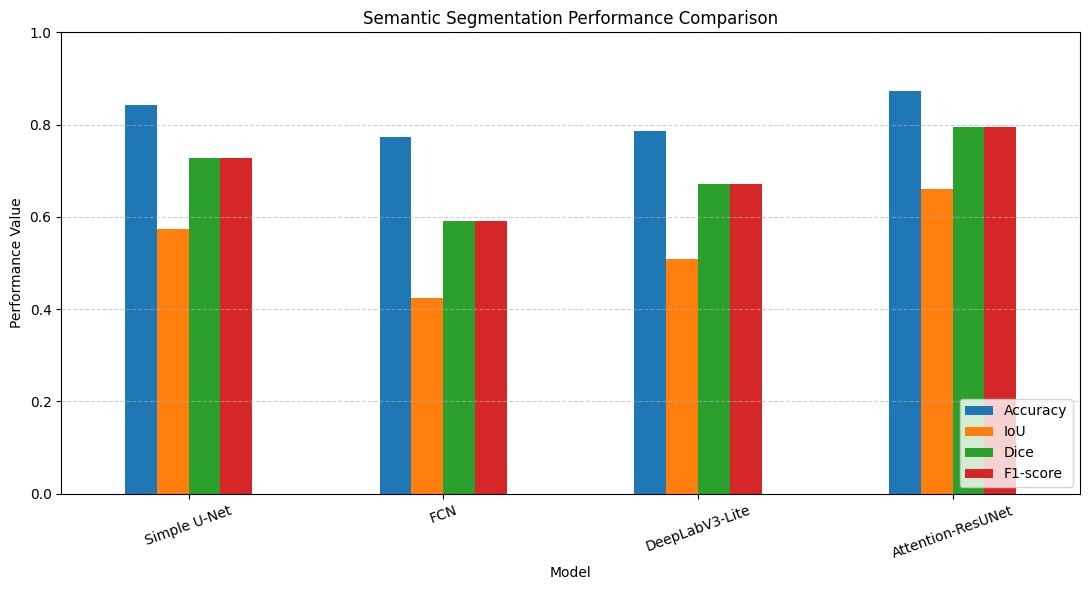

In [ ]:
import matplotlib.pyplot as plt

# I defined the list of evaluation metrics to visualize
metrics = ["Accuracy", "IoU", "Dice", "F1-score"]

# I plotted a bar chart comparing all models across selected metrics
df_results[metrics].plot(
    kind="bar",
    figsize=(11, 6)
)

# I set the title of the plot
plt.title("Semantic Segmentation Performance Comparison")

# I changed the y-axis label to a more descriptive term
plt.ylabel("Performance Value")

# I labeled the x-axis to represent different models
plt.xlabel("Model")

# I adjusted x-axis labels for better readability
plt.xticks(rotation=20)

# I set the y-axis range between 0 and 1 since metrics are normalized
plt.ylim(0, 1)

# I added grid lines for better visualization
plt.grid(axis="y", linestyle="--", alpha=0.6)

# I positioned the legend at the bottom right
plt.legend(loc="lower right")

# I adjusted layout to avoid overlap
plt.tight_layout()

# I displayed the final plot
plt.show()

# BAR PLOT - Only F1-Score

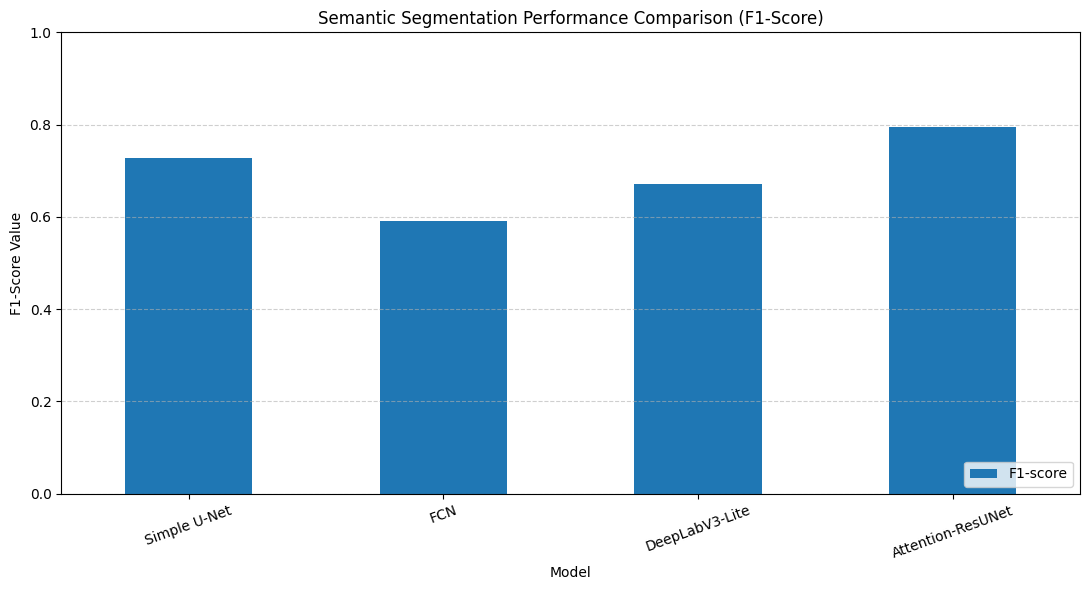

In [ ]:
import matplotlib.pyplot as plt

# I selected only the F1-score metric for visualization
metrics = ["F1-score"]

# I plotted a bar chart comparing models based on F1-score
df_results[metrics].plot(
    kind="bar",
    figsize=(11, 6)
)

# I set the title of the plot
plt.title("Semantic Segmentation Performance Comparison (F1-Score)")

# I updated the y-axis label to be more specific and meaningful
plt.ylabel("F1-Score Value")

# I labeled the x-axis to represent different models
plt.xlabel("Model")

# I adjusted x-axis labels for better readability
plt.xticks(rotation=20)

# I set the y-axis range between 0 and 1
plt.ylim(0, 1)

# I added grid lines for better clarity
plt.grid(axis="y", linestyle="--", alpha=0.6)

# I positioned the legend at the bottom right
plt.legend(loc="lower right")

# I adjusted layout to avoid overlap
plt.tight_layout()

# I displayed the plot
plt.show()

# Computing Metrics for ONE Image

In [ ]:
def compute_metrics_single(y_true, y_pred):
    # I computed the pixel-wise accuracy by comparing true and predicted values
    acc = np.mean(y_true == y_pred)

    # I calculated the Intersection over Union (IoU) by expanding dimensions
    # to match the expected input format of the metric function
    iou = iou_metric(y_true[np.newaxis, ...], y_pred[np.newaxis, ...]).numpy()

    # I calculated the Dice coefficient similarly by adding a batch dimension
    dice = dice_coef(y_true[np.newaxis, ...], y_pred[np.newaxis, ...]).numpy()

    # I returned all computed metrics: accuracy, IoU, and Dice score
    return acc, iou, dice

# Visualization

In [ ]:
def visualize_predictions_with_metrics(model, X, y, threshold=0.4, n=5):
    # I generated predictions for the first 'n' input samples
    preds = model.predict(X[:n])

    # I applied a threshold to convert probabilities into binary masks
    preds = (preds > threshold).astype(np.float32)

    # I created a figure to display images, ground truth, and predictions
    plt.figure(figsize=(14, 4*n))

    # I iterated through each sample to visualize results
    for i in range(n):
        # I computed evaluation metrics (Accuracy, IoU, Dice) for each sample
        acc, iou, dice = compute_metrics_single(
            y[i].squeeze(), preds[i].squeeze()
        )

        # I displayed the original satellite image
        plt.subplot(n, 3, i*3 + 1)
        plt.imshow(X[i])
        plt.title("Satellite Image")
        plt.axis("off")

        # I displayed the ground truth mask
        plt.subplot(n, 3, i*3 + 2)
        plt.imshow(y[i].squeeze(), cmap="gray")
        plt.title("Ground Truth Mask")
        plt.axis("off")

        # I displayed the predicted segmentation mask along with metrics
        plt.subplot(n, 3, i*3 + 3)
        plt.imshow(preds[i].squeeze(), cmap="gray")
        plt.title(
            f"Prediction\nAcc={acc:.2f}, IoU={iou:.2f}, Dice={dice:.2f}"
        )
        plt.axis("off")

    # I adjusted the layout to prevent overlapping of subplots
    plt.tight_layout()

    # I displayed the final visualization
    plt.show()

# Qualitative Results and Model Prediction Visualization

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


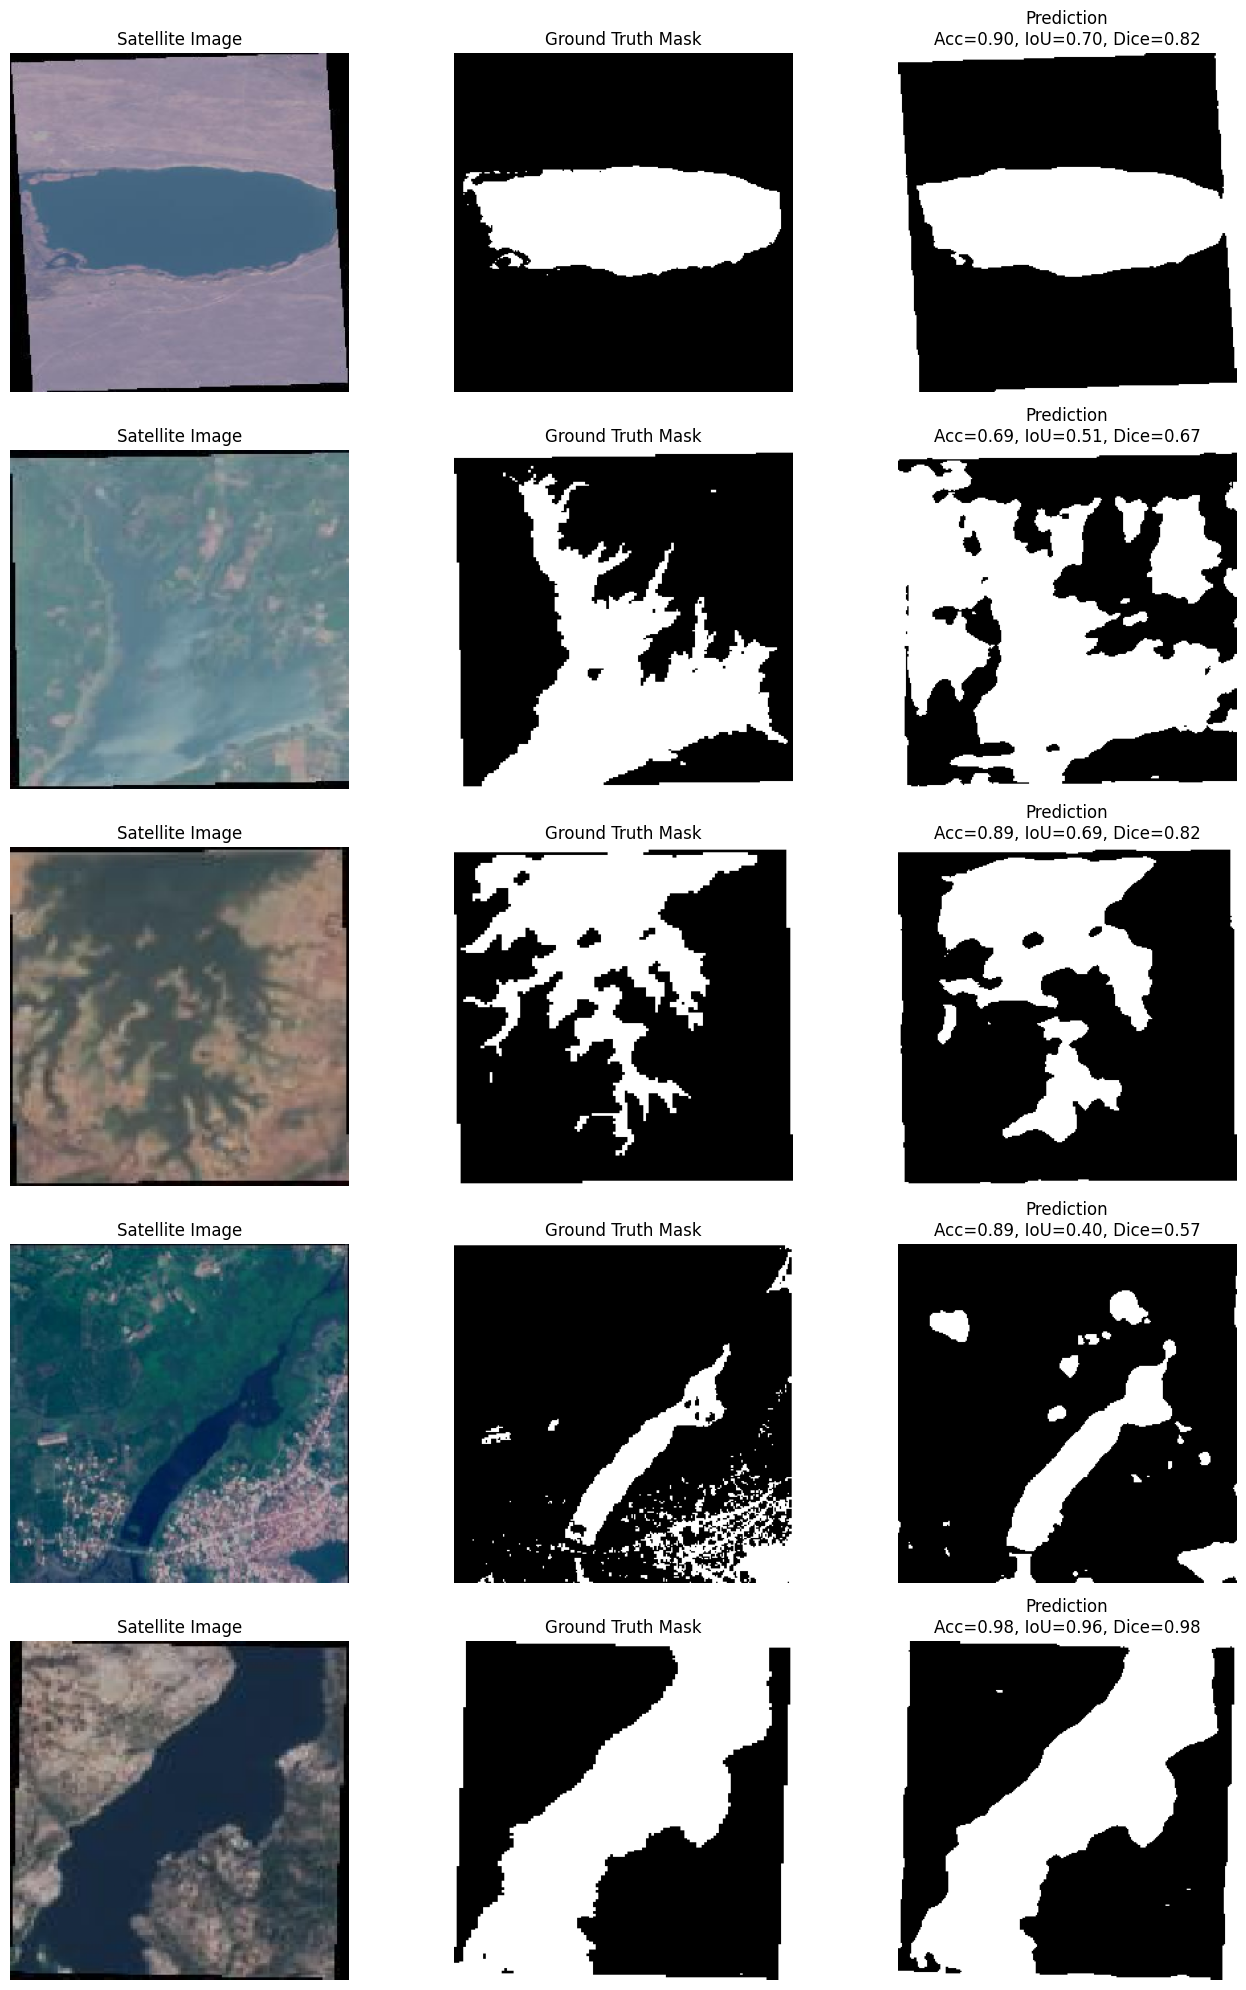

In [ ]:
# I called the visualization function to display predictions and metrics

visualize_predictions_with_metrics(
    model_improved,  # I passed the trained Improved U-Net model
    X_test,          # I provided the test input images
    y_test,          # I provided the corresponding ground truth masks
    threshold=0.4,   # I set a threshold to convert predicted probabilities into binary masks
    n=5              # I selected 5 samples for visualization
)

# Demo

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


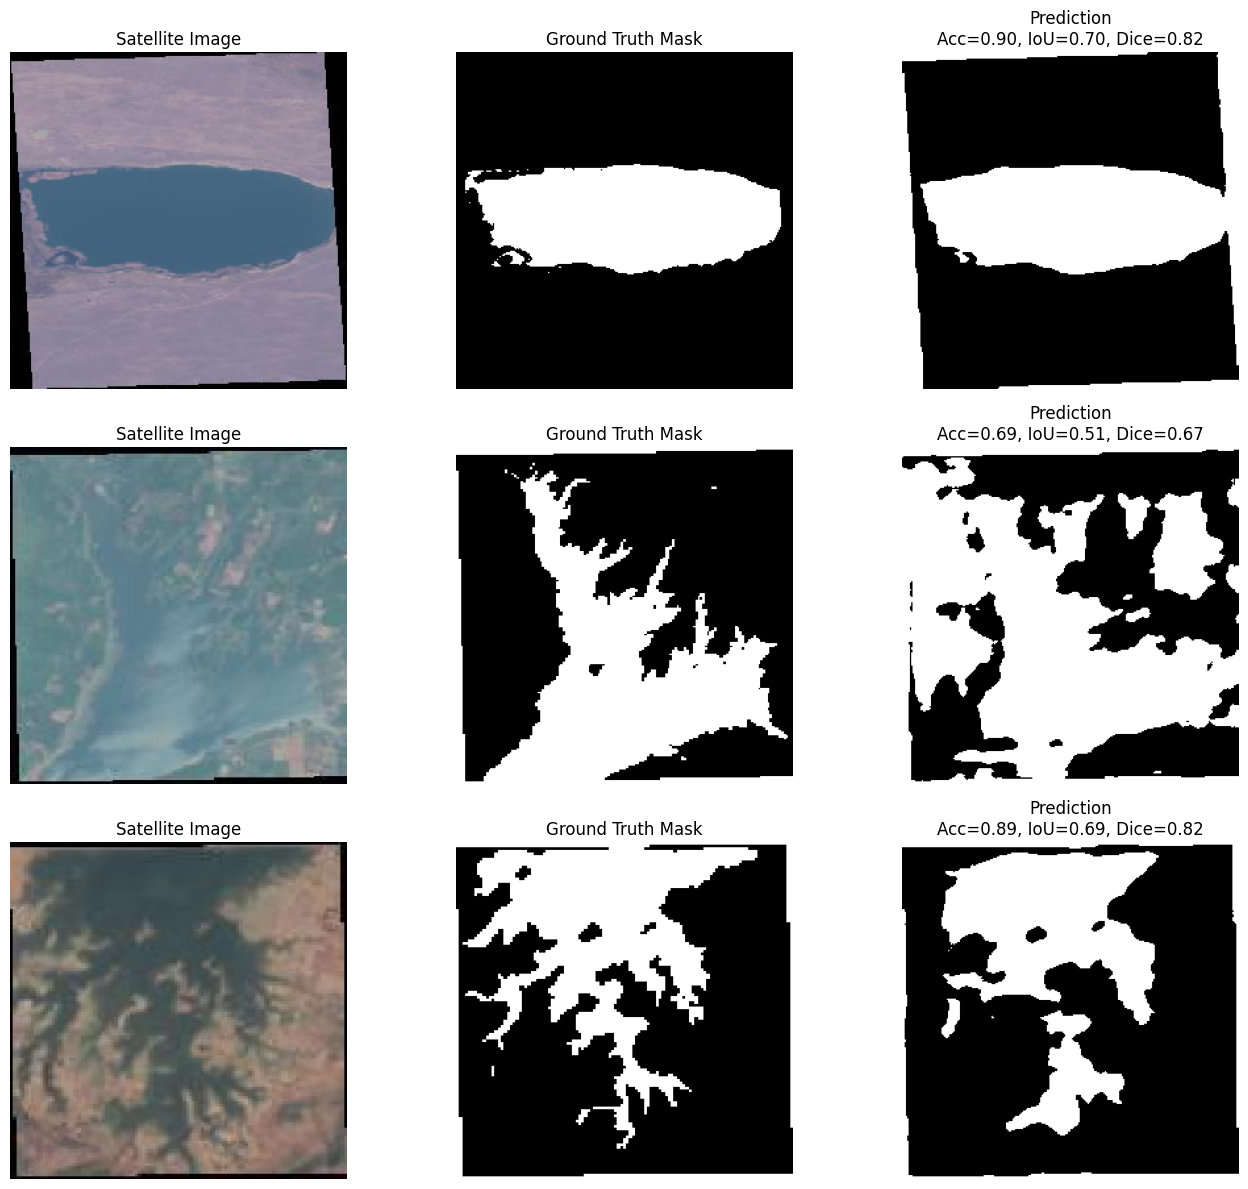


 MODEL COMPARISON TABLE 
                   Accuracy     IoU    Dice  F1-score
Simple U-Net         0.8420  0.5742  0.7280    0.7280
FCN                  0.7737  0.4234  0.5921    0.5921
DeepLabV3-Lite       0.7856  0.5079  0.6718    0.6718
Attention-ResUNet    0.8727  0.6600  0.7939    0.7939

 BEST MODEL 
Best Model: Attention-ResUNet
Best IoU: 0.6600


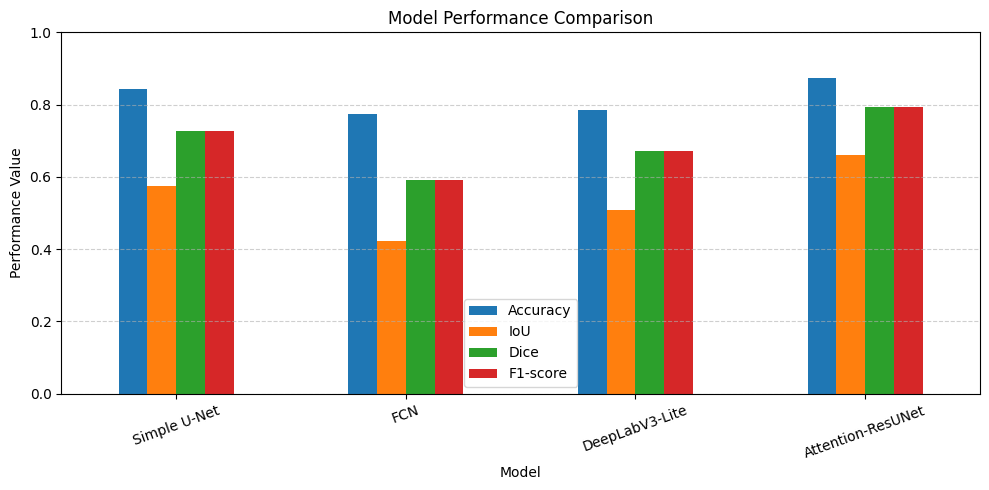

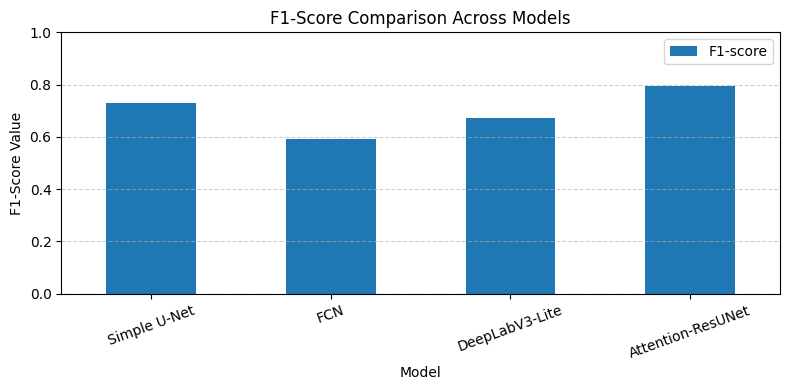

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


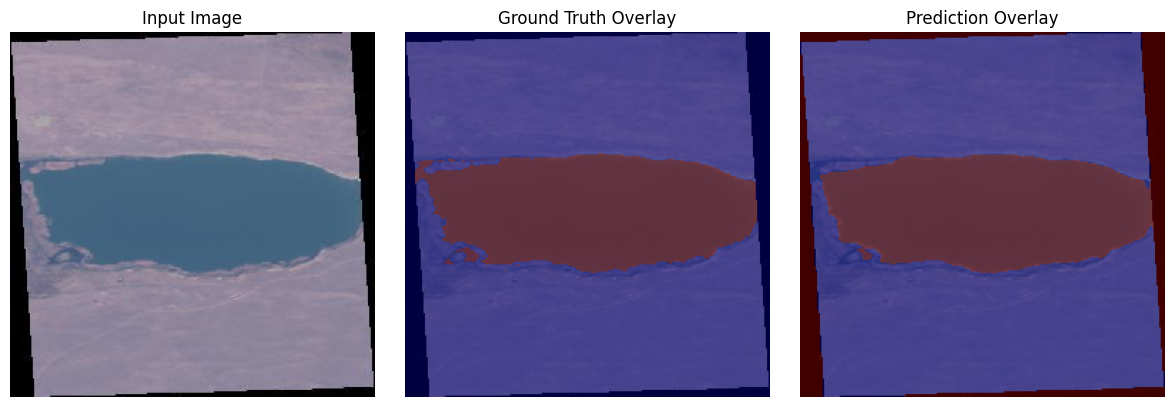


 CONFUSION MATRIX
[[43968  6209]
 [  283 15076]]

 ADDITIONAL METRICS 
Precision: 0.7083
Recall: 0.9816
F1-score: 0.8228

 PIXEL DISTRIBUTION 
Ground Truth Positive Pixels: 15359.0
Predicted Positive Pixels: 21285.0


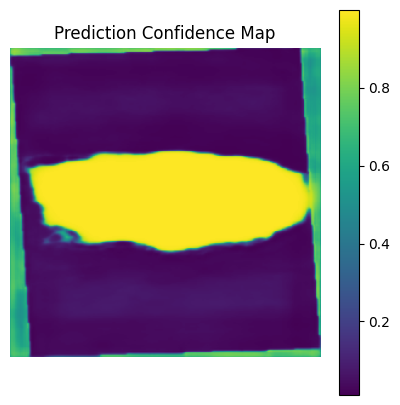


 MULTI-SAMPLE EVALUATION 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Sample 1 IoU: 0.8800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Sample 2 IoU: 0.8520
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Sample 3 IoU: 0.4961

 FINAL EVALUATION SUMMARY 
Simple U-Net -> IoU: 0.5742, Dice: 0.7280
FCN -> IoU: 0.4234, Dice: 0.5921
DeepLabV3-Lite -> IoU: 0.5079, Dice: 0.6718
Attention-ResUNet -> IoU: 0.6600, Dice: 0.7939


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# I visualized the model predictions along with evaluation metrics
visualize_predictions_with_metrics(
    model_improved,
    X_test,
    y_test,
    threshold=0.4,
    n=3
)

# I displayed the comparison table of all models
print("\n MODEL COMPARISON TABLE ")
print(df_results)

# I identified the best model based on IoU score
best_model = df_results["IoU"].idxmax()
best_iou = df_results["IoU"].max()

print("\n BEST MODEL ")
print(f"Best Model: {best_model}")
print(f"Best IoU: {best_iou:.4f}")

# I plotted a comparison graph for all evaluation metrics
df_results[["Accuracy", "IoU", "Dice", "F1-score"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Performance Value")
plt.xlabel("Model")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# I plotted only the F1-score to highlight performance differences clearly
df_results[["F1-score"]].plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("F1-Score Comparison Across Models")
plt.ylabel("F1-Score Value")
plt.xlabel("Model")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# I selected a single test sample to demonstrate prediction quality visually
idx = 0  # I chose the first test sample

img = X_test[idx]
true_mask = y_test[idx].squeeze()

# I generated the predicted mask using the trained model
pred = model_improved.predict(np.expand_dims(img, axis=0))[0]
pred_mask = (pred > 0.4).astype(np.float32).squeeze()

plt.figure(figsize=(12,4))

# I displayed the original input image
plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")

# I overlaid the ground truth mask on the original image
plt.subplot(1,3,2)
plt.imshow(img)
plt.imshow(true_mask, cmap="jet", alpha=0.5)
plt.title("Ground Truth Overlay")
plt.axis("off")

# I overlaid the predicted mask on the original image
plt.subplot(1,3,3)
plt.imshow(img)
plt.imshow(pred_mask, cmap="jet", alpha=0.5)
plt.title("Prediction Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

# I computed pixel-wise confusion matrix for segmentation performance
y_true_flat = true_mask.flatten()
y_pred_flat = pred_mask.flatten()

cm = confusion_matrix(y_true_flat, y_pred_flat)

print("\n CONFUSION MATRIX")
print(cm)

# I calculated precision, recall, and F1-score manually for deeper evaluation
TP = cm[1,1]
TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]

precision = TP / (TP + FP + 1e-7)
recall = TP / (TP + FN + 1e-7)
f1 = 2 * (precision * recall) / (precision + recall + 1e-7)

print("\n ADDITIONAL METRICS ")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# I compared prediction vs ground truth pixel distribution
print("\n PIXEL DISTRIBUTION ")
print(f"Ground Truth Positive Pixels: {np.sum(true_mask)}")
print(f"Predicted Positive Pixels: {np.sum(pred_mask)}")

# I visualized prediction confidence map (probability output)
plt.figure(figsize=(5,5))
plt.imshow(pred.squeeze(), cmap="viridis")
plt.title("Prediction Confidence Map")
plt.colorbar()
plt.axis("off")
plt.show()

# I evaluated multiple random samples for robustness
print("\n MULTI-SAMPLE EVALUATION ")
for i in range(3):
    idx = np.random.randint(0, len(X_test))
    img = X_test[idx]
    true_mask = y_test[idx].squeeze()

    pred = model_improved.predict(np.expand_dims(img, axis=0))[0]
    pred_mask = (pred > 0.4).astype(np.float32).squeeze()

    iou = np.sum((pred_mask * true_mask)) / (
        np.sum(pred_mask) + np.sum(true_mask) - np.sum(pred_mask * true_mask) + 1e-7
    )

    print(f"Sample {i+1} IoU: {iou:.4f}")

# I printed the final evaluation summary for all models
print("\n FINAL EVALUATION SUMMARY ")
for model_name, metrics in results.items():
    print(f"{model_name} -> IoU: {metrics['IoU']:.4f}, Dice: {metrics['Dice']:.4f}")